# Contact Resistance and the Transfer Length Method (TLM)

Every measurement of a semiconductor layer is made *through* a contact. The
number a probe station reports is therefore always a sum: the resistance of
the layer you wanted to measure, plus the resistance of getting current
into and out of it. Those two are not separable from a single measurement.

The Transfer Length Method separates them, using nothing more than a set of
identical contacts placed at different distances apart. From one straight
line it returns four quantities:

| Symbol | Quantity | Units |
|---|---|---|
| $R_S$ | sheet resistance of the layer | $\Omega/\square$ |
| $R_C$ | resistance of one contact | $\Omega$ |
| $L_T$ | transfer length | mm |
| $\rho_C$ | specific contact resistivity | $\Omega\,\text{cm}^2$ |

This notebook builds the method up in order:

| Section | Question answered |
|---|---|
| 1 | What does a two-probe measurement actually contain? |
| 2 | What does the layer alone contribute? |
| 3 | Why does the contact term not vanish as the spacing shrinks? |
| 4 | Where does current actually cross the interface? |
| 5 | What is the transfer length, and what sets it? |
| 6 | How do those pieces combine into the TLM equation? |
| 7-8 | How is the measurement made, and reduced to one number per spacing? |
| 9 | How are $R_S$, $R_C$, $L_T$ and $\rho_C$ extracted, with uncertainties? |
| 10 | Which errors matter, and how much? |
| 11 | When does the method break down, and how would you know? |
| 12 | How do I run this on my own measurements? |

<div align="center">
   <img src="./figures/fig_tlm_resistance_chain.jpg" width="640">
</div>

Equations are numbered (1), (2), ... and referred to by those numbers
throughout. All physics and fitting functions live in
[`tlm_helper.py`](./tlm_helper.py), so the notebook itself stays short;
that module's docstrings point back to these equation numbers.

In [1]:
# --- Google Colab setup -------------------------------------------------
# Colab opens this notebook file on its own, without the rest of the
# repository, so tlm_helper.py and figures/ would be missing. This cell
# clones the repo and switches into the TLM folder when (and only when)
# running on Colab. It does nothing when you run the notebook locally.
import os
import sys
import subprocess

if "google.colab" in sys.modules and not os.path.exists("tlm_helper.py"):
    REPO_URL = "https://github.com/Oxford-eMat-Lab/semiconductor-characterisation.git"
    subprocess.run(["git", "clone", "-q", REPO_URL, "/content/semicon"], check=True)
    os.chdir("/content/semicon/TLM")
    print("Colab setup complete, working directory:", os.getcwd())

## 1. What a two-probe measurement contains

Put two metal contacts on a conducting layer, force a current through one
and out of the other, and measure the voltage. The resistance you get is a
series chain:

$$
R_T = 2R_m + 2R_C + R_{\text{semi}} \tag{1}
$$

- $R_m$ — resistance of the metal itself and of the leads,
- $R_C$ — resistance of **one** metal/semiconductor interface,
- $R_{\text{semi}}$ — resistance of the semiconductor between the contacts.

The metal term is small (metals are orders of magnitude more conductive
than a doped semiconductor layer) and, with four-wire probing, the leads
are excluded from the measurement altogether. So Eq. (1) is used as

$$
R_T \simeq 2R_C + R_{\text{semi}}
$$

Two unknowns, one measurement. Nothing in a single reading tells you how
the total splits between them — which is exactly the problem TLM solves.

## 2. What the layer alone contributes

The semiconductor term is set by the **sheet resistance** of the layer,

$$
R_S = \frac{\rho}{t} \tag{2}
$$

where $\rho$ is the bulk resistivity ($\Omega\,\text{cm}$) and $t$ the
layer thickness. $R_S$ has units of $\Omega/\square$ — ohms per square —
because any *square* patch of the layer has the same edge-to-edge
resistance whatever its size. A rectangle of length $L$ and width $W$ is
just $L/W$ squares in series:

$$
R_{\text{semi}} = R_S \frac{L}{W} \tag{3}
$$

Sheet resistance is the natural way to describe a thin layer: it separates
what the material is ($\rho$) and how thick it is ($t$) from how it has
been patterned ($L/W$).

The cell below shows what each of the three inputs does to a measured I-V
curve of a contact-free strip. Note which ones change the slope and by how
much.

baseline sheet resistance R_S = 100 ohm/sq
strip resistance at L = 1 mm, W = 5 mm: 20.0 ohm


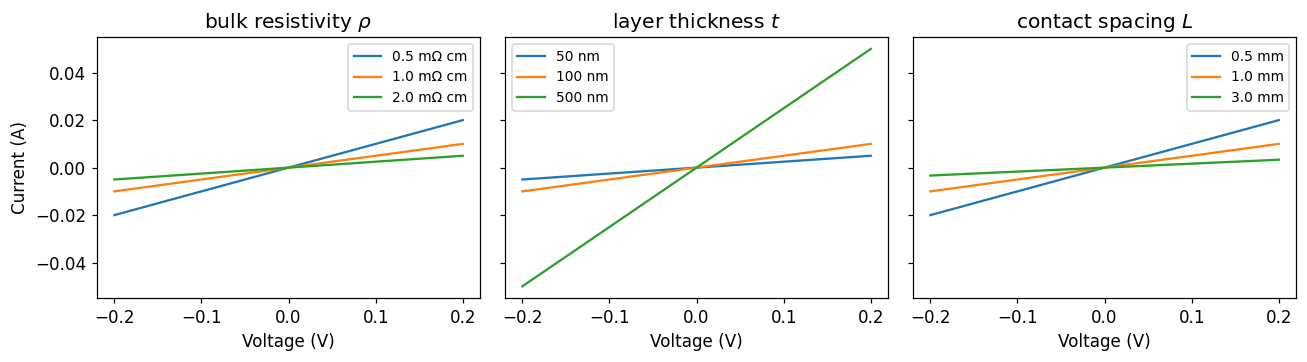

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tlm_helper as th

plt.rcParams.update({'font.size': 11})

V = np.linspace(-0.2, 0.2, 201)
rho0, t0, L0, W0 = 1e-3, 100e-7, 1.0, 5.0    # ohm.cm, cm, mm, mm

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)

for rho in [5e-4, 1e-3, 2e-3]:                        # Eq. (2)
    Rs = th.sheet_resistance(rho, t0)
    axes[0].plot(V, th.iv_curve(V, Rs, L0, W0), label=f'{rho*1e3:.1f} mΩ cm')
axes[0].set_title('bulk resistivity $\\rho$')

for t in [50e-7, 100e-7, 500e-7]:                     # Eq. (2)
    Rs = th.sheet_resistance(rho0, t)
    axes[1].plot(V, th.iv_curve(V, Rs, L0, W0), label=f'{t*1e7:.0f} nm')
axes[1].set_title('layer thickness $t$')

Rs0 = th.sheet_resistance(rho0, t0)
for L in [0.5, 1.0, 3.0]:                             # Eq. (3)
    axes[2].plot(V, th.iv_curve(V, Rs0, L, W0), label=f'{L:.1f} mm')
axes[2].set_title('contact spacing $L$')

for ax in axes:
    ax.set_xlabel('Voltage (V)'); ax.legend(fontsize=9)
axes[0].set_ylabel('Current (A)')
plt.tight_layout(); plt.show()

print(f"baseline sheet resistance R_S = {Rs0:.0f} ohm/sq")
print(f"strip resistance at L = 1 mm, W = 5 mm: "
      f"{th.strip_resistance(Rs0, 1.0, 5.0):.1f} ohm")

Three different knobs, one visible effect: the slope. A single I-V
curve cannot tell you *which* of them changed — and, once contacts are
added, it cannot tell you whether the layer or the interface is
responsible either.

## 3. Why the contact term does not vanish

Combining Eqs. (1) and (3) gives the relation TLM is built on:

$$
R_T(L) = R_S \frac{L}{W} + 2R_C \tag{4}
$$

Measure $R_T$ at several contact spacings $L$ and this is a straight line:

- the **slope** is $R_S/W$ — the layer,
- the **intercept** at $L = 0$ is $2R_C$ — the contacts.

The contact term is the part that *survives* extrapolating the spacing to
zero. That is the whole trick: the two contributions have different
dependences on $L$, so varying $L$ separates them.

<div align="center">
   <img src="./figures/fig_tlm_structure.jpg" width="680">
</div>

A TLM test structure is built to do exactly this: one isolated strip of the
layer under test, a row of identical contacts on top of it, and a set of
different gaps between neighbouring contacts. Every neighbouring pair gives
one point on the line.

## 4. Where the current actually crosses

$R_C$ on its own is not a useful figure of merit: make the contact bigger
and $R_C$ falls, so quoting it says as much about the mask as about the
process. The transferable quantity is the **specific contact resistivity**

$$
\rho_C = R_C\, A_{\text{eff}} \tag{5}
$$

in $\Omega\,\text{cm}^2$ — the resistance of a unit area of interface.
Lower is better.

That leaves the question of what $A_{\text{eff}}$ is. In an idealised bar
with contacts on the end faces it is obvious. In a real planar structure
the contact sits on *top* of the layer, and current does not enter it
uniformly: it takes the least-resistive route, which means crossing into
the metal as soon as it can. Current **crowds** at the leading edge of the
contact and dies away underneath it.

<div align="center">
   <img src="./figures/fig_tlm_crowding.jpg" width="760">
</div>

Solving the distributed network of sheet resistance and interface
resistance under the contact gives an exponential decay,

$$
I(x) = I_0\, e^{-x/L_T} \tag{6}
$$

with $x$ measured from the leading edge. So the drawn contact length is not
what matters — the decay length is.

## 5. The transfer length

The decay length in Eq. (6) is the **transfer length**

$$
L_T = \sqrt{\frac{\rho_C}{R_S}} \tag{7}
$$

Read it as a competition between two paths: travelling further sideways in
the sheet (cost set by $R_S$) versus crossing the interface here and now
(cost set by $\rho_C$). A good contact — small $\rho_C$ — pulls current in
almost immediately and has a short $L_T$; a poor contact lets current run
far under the metal before crossing.

$L_T$ answers the area question. The effective area is the contact width
times one transfer length,

$$
A_{\text{eff}} = L_T W \tag{8}
$$

so one contact has resistance

$$
R_C = \frac{\rho_C}{L_T W} = \frac{R_S L_T}{W} \tag{9}
$$

There is a practical consequence in Eq. (8): extending a contact beyond a
few $L_T$ adds area but no current path. The cell below shows both the
decay and where the resistance stops improving.

rho_C = 1e-04 ohm.cm^2  ->  L_T =    6.3 um, R_C = 0.158 ohm
rho_C = 1e-03 ohm.cm^2  ->  L_T =   20.0 um, R_C = 0.500 ohm
rho_C = 1e-02 ohm.cm^2  ->  L_T =   63.2 um, R_C = 1.581 ohm


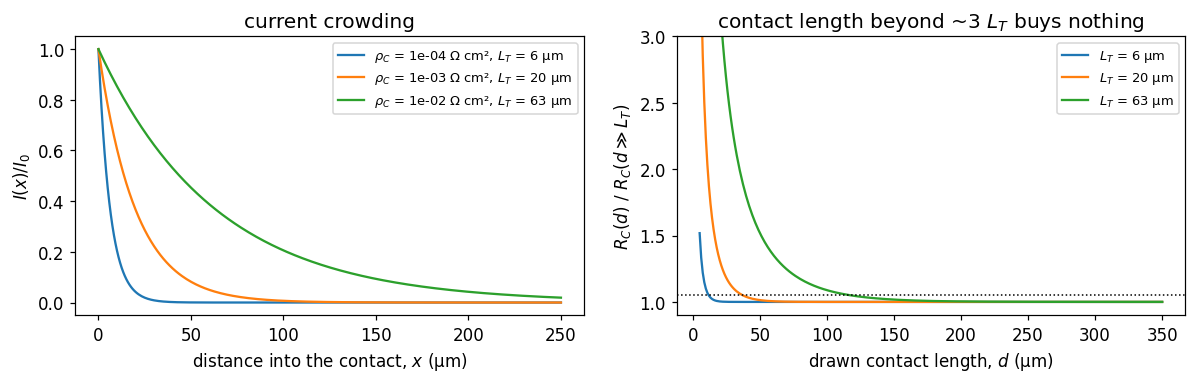

In [3]:
Rs = 250.0        # ohm/sq, a typical doped emitter
W = 10.0          # mm, contact width

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 3.6))

# --- left: current decay under the contact, for three contact qualities
x_um = np.linspace(0, 250, 300)
for rho_c in [1e-4, 1e-3, 1e-2]:
    LT = th.transfer_length_mm(rho_c, Rs)                       # Eq. (7)
    axL.plot(x_um, th.current_under_contact(x_um * 1e-3, LT),   # Eq. (6)
             label=f'$\\rho_C$ = {rho_c:.0e} Ω cm², $L_T$ = {LT*1e3:.0f} µm')
axL.set_xlabel('distance into the contact, $x$ (µm)')
axL.set_ylabel('$I(x)/I_0$')
axL.legend(fontsize=8.5); axL.set_title('current crowding')

# --- right: why long contacts stop helping
d_um = np.linspace(5, 350, 300)
for rho_c in [1e-4, 1e-3, 1e-2]:
    LT = th.transfer_length_mm(rho_c, Rs)
    Rc_d = th.contact_resistance(Rs, LT, W, d_mm=d_um * 1e-3)   # Eq. (9), full form
    axR.plot(d_um, Rc_d / th.contact_resistance(Rs, LT, W),
             label=f'$L_T$ = {LT*1e3:.0f} µm')
axR.axhline(1.05, ls=':', color='k', lw=1)
axR.set_xlabel('drawn contact length, $d$ (µm)')
axR.set_ylabel('$R_C(d)\\ /\\ R_C(d \\gg L_T)$')
axR.set_ylim(0.9, 3); axR.legend(fontsize=8.5)
axR.set_title('contact length beyond ~3 $L_T$ buys nothing')

plt.tight_layout(); plt.show()

for rho_c in [1e-4, 1e-3, 1e-2]:
    LT = th.transfer_length_mm(rho_c, Rs)
    print(f"rho_C = {rho_c:.0e} ohm.cm^2  ->  L_T = {LT*1e3:6.1f} um, "
          f"R_C = {th.contact_resistance(Rs, LT, W):.3f} ohm")

## 6. The TLM equation

Substituting Eq. (9) into Eq. (4) collapses everything into one line:

$$
R_T(L) = \frac{R_S}{W}\left(L + 2L_T\right) \tag{10}
$$

Plot $R_T$ against $L$ and read off:

| Feature of the line | Gives |
|---|---|
| slope | $R_S / W$ |
| $y$-intercept | $2R_C$ |
| $x$-intercept | $-2L_T$ |
| combined | $\rho_C = R_S L_T^2$ |

<div align="center">
   <img src="./figures/fig_tlm_plot.jpg" width="720">
</div>

Note what the $x$-intercept means physically. The line does not hit zero
resistance at zero spacing — it hits zero at a *negative* spacing, as if the
current had to travel an extra $L_T$ under each contact. That is precisely
what it does.

## 7. Making the measurement

Each point on that line comes from a voltage sweep across one pair of
contacts.

<div align="center">
   <img src="./figures/fig_tlm_measurement.jpg" width="720">
</div>

Two details decide whether the extraction will be any good:

- **Four-wire probing.** The force leads carry the current; separate sense
  leads measure the voltage where no current flows through them, so probe
  and lead resistance drop out. In two-wire mode that resistance is the
  same at every spacing — it adds straight into the intercept and is
  indistinguishable from contact resistance.
- **A sweep, not a single point.** Fitting the slope of $I(V)$ rejects any
  current offset, and the *shape* of the curve is the evidence that the
  contact is ohmic at all.

The cell below generates a synthetic dataset from the model above — known
$R_S$ and $\rho_C$, so the extraction can be checked against the truth —
with realistic current noise and a small random error on the actual
contact spacings.

ground truth used to generate the data:
   Rs_ohm_sq        250
   rho_c_ohm_cm2    0.0015
   LT_mm            0.02449
   Rc_ohm           0.6124


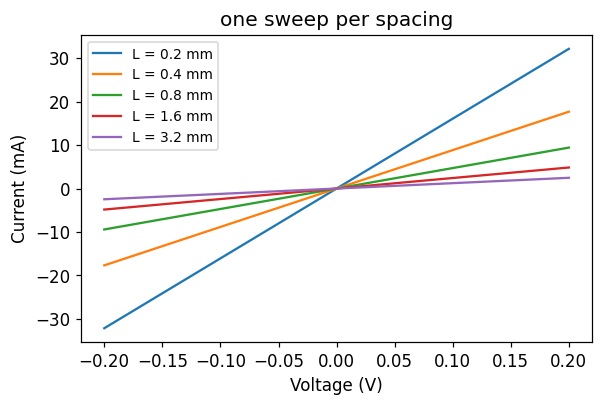

In [4]:
spacings_mm = np.array([0.2, 0.4, 0.8, 1.6, 3.2])

data = th.synthetic_tlm_dataset(
    spacings_mm,
    Rs_ohm_sq=250.0,          # the layer we are pretending to measure
    rho_c_ohm_cm2=1.5e-3,     # the contact we are pretending to have
    W_mm=10.0,
    n_repeats=4,              # four nominally identical structures each
    noise_pA=400.0,           # source-meter current noise
    spacing_error_um=8.0,     # lithography / probe placement error
    seed=7,
)

print("ground truth used to generate the data:")
for k, v in data['truth'].items():
    print(f"   {k:16s} {v:.4g}")

plt.figure(figsize=(5.6, 3.8))
for i, L in enumerate(data['spacings_mm']):
    plt.plot(data['V'], data['I'][i, 0] * 1e3, label=f'L = {L:.1f} mm')
plt.xlabel('Voltage (V)'); plt.ylabel('Current (mA)')
plt.legend(fontsize=9); plt.title('one sweep per spacing')
plt.tight_layout(); plt.show()

## 8. From sweeps to one resistance per spacing

Each sweep is reduced by fitting

$$
I = \frac{V}{R_T} + I_{\text{offset}} \tag{11}
$$

and taking $R_T$ from the slope. Repeated structures at the same spacing
are then averaged, and their spread becomes the error bar on that point —
which will be used to weight the TLM fit later.

Before averaging anything, check that each curve is actually a straight
line. The $R^2$ of the fit is a cheap, quantitative version of "the I-V
looked fine".

  L (mm)     R_T (Ω)   spread (Ω)    min R²
    0.20       6.352       0.1708   1.00000
    0.40      11.248       0.1152   1.00000
    0.80      21.255       0.1058   1.00000
    1.60      41.244       0.1201   1.00000
    3.20      81.223       0.1572   1.00000


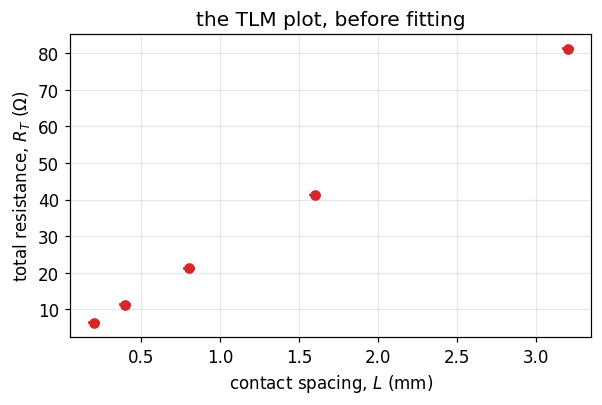

In [5]:
L, R_mean, R_std, R_all = th.resistances_per_spacing(data)   # Eq. (11)

print(f"{'L (mm)':>8}  {'R_T (Ω)':>10}  {'spread (Ω)':>11}  {'min R²':>8}")
for i, Li in enumerate(L):
    r2 = min(th.iv_linearity(data['V'], data['I'][i, j])
             for j in range(data['I'].shape[1]))
    print(f"{Li:8.2f}  {R_mean[i]:10.3f}  {R_std[i]:11.4f}  {r2:8.5f}")

plt.figure(figsize=(5.6, 3.8))
plt.errorbar(L, R_mean, yerr=R_std, fmt='o', capsize=4, color='C3')
plt.xlabel('contact spacing, $L$ (mm)')
plt.ylabel('total resistance, $R_T$ (Ω)')
plt.title('the TLM plot, before fitting')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 9. The extraction

Fit $R_T = mL + b$ and unpack it — Eq. (10) term by term:

$$
R_S = m\,W \tag{12}
$$

$$
R_C = \frac{b}{2} \tag{13}
$$

$$
L_T = \frac{b}{2m} \tag{14}
$$

$$
\rho_C = R_S L_T^2 \tag{15}
$$

Two things are worth doing properly here, and `tlm_helper.fit_tlm` does
both:

- **Weight the fit** by the measured spread at each spacing, so a noisy
  point does not drag the intercept.
- **Propagate the fit covariance**, not just the individual standard
  errors. The slope and intercept of a line fitted over a limited range are
  strongly anti-correlated, and $L_T$ depends on their *ratio*; ignoring
  the correlation overstates its uncertainty.

$W$ enters Eqs. (12) and (15) directly, so measure the contact width rather
than trusting the mask drawing.

TLM extraction
--------------
  fit           R_T = 24.98 * L + 1.282   (R^2 = 1.00000)
  contact width W       = 10 mm
  sheet resist. R_S     = 249.8 +/- 0.18 ohm/sq
  contact res.  R_C     = 0.6409 +/- 0.013 ohm
  transfer len. L_T     = 0.02566 +/- 0.00053 mm
  contact resy. rho_C   = 0.001645 +/- 6.8e-05 ohm.cm^2

recovered / true:
   R_S    0.999
   rho_C  1.096


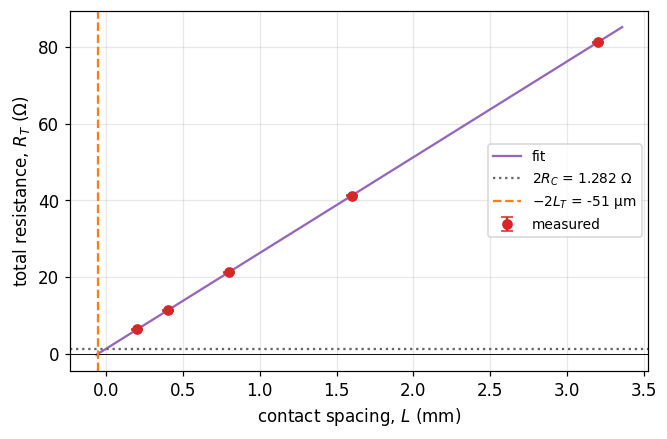

In [6]:
res = th.fit_tlm(L, R_mean, W_mm=data['W_mm'], sigma_ohm=R_std)
print(res.summary())

truth = data['truth']
print("\nrecovered / true:")
print(f"   R_S    {res.Rs_ohm_sq / truth['Rs_ohm_sq']:.3f}")
print(f"   rho_C  {res.rho_c_ohm_cm2 / truth['rho_c_ohm_cm2']:.3f}")

# the plot, with the two intercepts marked
x = np.linspace(-2.5 * res.LT_mm, L.max() * 1.05, 100)
plt.figure(figsize=(6.2, 4.1))
plt.errorbar(L, R_mean, yerr=R_std, fmt='o', capsize=4, color='C3',
             label='measured', zorder=3)
plt.plot(x, res.slope_ohm_per_mm * x + res.intercept_ohm, '-', color='C4',
         label='fit')
plt.axhline(0, color='k', lw=0.6)
plt.axhline(res.intercept_ohm, ls=':', color='0.4',
            label=f'$2R_C$ = {res.intercept_ohm:.3f} Ω')
plt.axvline(-2 * res.LT_mm, ls='--', color='C1',
            label=f'$-2L_T$ = {-2*res.LT_mm*1e3:.0f} µm')
plt.xlabel('contact spacing, $L$ (mm)')
plt.ylabel('total resistance, $R_T$ (Ω)')
plt.legend(fontsize=9); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Look at the two ratios printed above. The sheet resistance comes back
within a fraction of a percent of the value used to generate the data;
$\rho_C$ is out by around ten percent — from the *same* fit, on the *same*
data. That asymmetry is not an accident, and it is the central practical
fact about TLM.

## 10. Which errors matter

$R_S$ comes from the **slope**, which is constrained by every point across
the whole range of spacings. $\rho_C$ comes from the **intercept**, an
extrapolation beyond the smallest spacing measured, and then gets squared:

$$
\rho_C = R_S L_T^2 = (mW)\left(\frac{b}{2m}\right)^2 = \frac{W b^2}{4m}
\quad\Rightarrow\quad
\frac{\Delta\rho_C}{\rho_C} \approx 2\,\frac{\Delta b}{b} \tag{16}
$$

A 10% error on the intercept is a 20% error on $\rho_C$. Anything that
adds a constant offset to every measured $R_T$ — two-wire probing, a
contact resistance in the probe tips, a systematic spacing error — lands
entirely in $b$ and is invisible in the quality of the fit.

Because $\rho_C$ depends on the square of a fitted ratio, its error
distribution is skewed rather than Gaussian, so a Monte-Carlo over the
measured scatter is more honest than a $\pm$ number.

Rs_ohm_sq       median    249.7 Ω/sq     68% interval [249.1, 250.3]  (±0.2%)
rho_c_ohm_cm2   median    1.692 mΩ cm²   68% interval [1.459, 1.942]  (±14.3%)


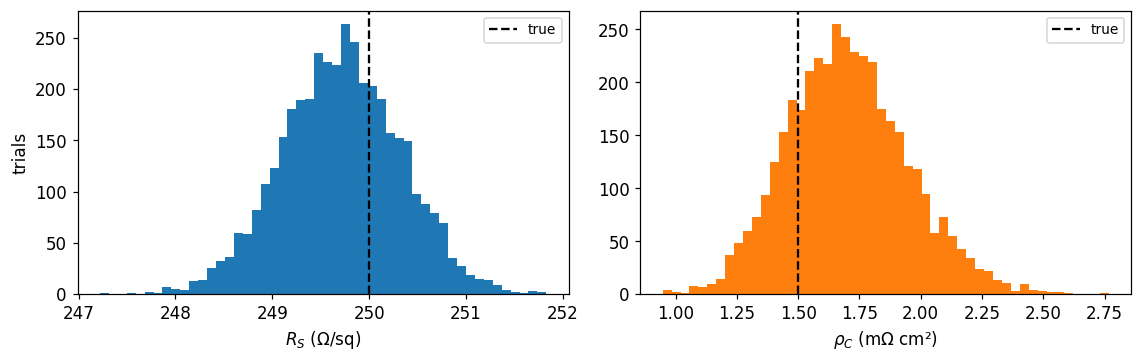

In [7]:
mc = th.monte_carlo_uncertainty(L, R_mean, R_std, W_mm=data['W_mm'],
                                n_trials=4000, seed=3)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.5, 3.4))
a1.hist(mc['Rs_ohm_sq'], bins=50, color='C0')
a1.axvline(truth['Rs_ohm_sq'], color='k', ls='--', label='true')
a1.set_xlabel('$R_S$ (Ω/sq)'); a1.set_ylabel('trials'); a1.legend(fontsize=9)

a2.hist(mc['rho_c_ohm_cm2'] * 1e3, bins=50, color='C1')
a2.axvline(truth['rho_c_ohm_cm2'] * 1e3, color='k', ls='--', label='true')
a2.set_xlabel('$\\rho_C$ (mΩ cm²)'); a2.legend(fontsize=9)
plt.tight_layout(); plt.show()

for key, unit, scale in [('Rs_ohm_sq', 'Ω/sq', 1), ('rho_c_ohm_cm2', 'mΩ cm²', 1e3)]:
    v = mc[key] * scale
    lo, hi = np.percentile(v, [16, 84])
    print(f"{key:15s} median {np.median(v):8.4g} {unit:8s} "
          f"68% interval [{lo:.4g}, {hi:.4g}]  "
          f"(±{100*(hi-lo)/2/np.median(v):.1f}%)")

A second, more insidious error is a **systematic offset** on $R_T$:
every point shifted by the same amount. The fit stays perfectly straight,
$R^2$ stays at 1, and only $\rho_C$ moves. The cell below adds a 0.2 Ω
probe resistance — the kind of thing two-wire probing gives you for
free — and refits.

In [8]:
offsets = [0.0, 0.1, 0.2, 0.5]
print(f"{'offset (Ω)':>11}  {'R_S (Ω/sq)':>11}  {'rho_C (mΩcm²)':>14}  {'R²':>8}")
for off in offsets:
    r = th.fit_tlm(L, R_mean + off, W_mm=data['W_mm'], sigma_ohm=R_std)
    print(f"{off:11.2f}  {r.Rs_ohm_sq:11.1f}  "
          f"{r.rho_c_ohm_cm2*1e3:14.3f}  {r.r_squared:8.5f}")

print(f"\ntrue rho_C = {truth['rho_c_ohm_cm2']*1e3:.3f} mΩcm²")
print("R_S is untouched; rho_C is not, and the fit quality never warns you.")

 offset (Ω)   R_S (Ω/sq)   rho_C (mΩcm²)        R²
       0.00        249.8           1.645   1.00000
       0.10        249.8           1.911   1.00000
       0.20        249.8           2.198   1.00000
       0.50        249.8           3.178   1.00000

true rho_C = 1.500 mΩcm²
R_S is untouched; rho_C is not, and the fit quality never warns you.


## 11. When TLM breaks down

The extraction assumes:

1. the sheet resistance is uniform, and the same under the contacts as
   between them;
2. all contacts are identical;
3. metal and lead resistance are negligible;
4. current flow is one-dimensional along the strip (contacts span the full
   width of an isolated mesa);
5. the contacts are ohmic, so $R_T$ is well defined;
6. $R_T$ vs $L$ is linear over the measured range.

Two failures dominate in practice.

**The transfer length is not small compared with the spacings.** The
intercept is an extrapolation from the smallest $L$ measured down to zero.
If $L_T$ is a large fraction of $L_{\max}$, that extrapolation — and hence
$\rho_C$ — is barely constrained by the data. A working rule: the largest
spacing should be several times $L_T$, and the smallest spacing should be
as small as the process allows.

**The contacts are not ohmic.** A rectifying interface gives an S-shaped
I-V, and the "resistance" you extract then depends on the voltage window
you happened to sweep. Fitting a line to it produces a number, no warning,
and a meaningless $\rho_C$.

`tlm_helper.tlm_validity_report` checks the first family of problems
mechanically; the second needs looking at the I-V curves.

In [9]:
# --- failure mode 1: spacings too small to pin down a long L_T ---
bad = th.synthetic_tlm_dataset(
    np.array([0.10, 0.15, 0.20, 0.25, 0.30]),   # all spacings tiny
    Rs_ohm_sq=250.0, rho_c_ohm_cm2=5e-2,        # and a poor contact
    W_mm=10.0, n_repeats=4, noise_pA=400.0, spacing_error_um=8.0, seed=11)

L_b, R_b, S_b, _ = th.resistances_per_spacing(bad)
res_b = th.fit_tlm(L_b, R_b, W_mm=bad['W_mm'], sigma_ohm=S_b)

print(res_b.summary())
print(f"\ntrue L_T = {bad['truth']['LT_mm']:.3f} mm, "
      f"largest spacing = {L_b.max():.2f} mm")
print("\nvalidity report:")
for w in th.tlm_validity_report(res_b):
    print("  ! " + w)

TLM extraction
--------------
  fit           R_T = 25.2 * L + 7.074   (R^2 = 0.99976)
  contact width W       = 10 mm
  sheet resist. R_S     = 252 +/- 1.6 ohm/sq
  contact res.  R_C     = 3.537 +/- 0.016 ohm
  transfer len. L_T     = 0.1404 +/- 0.0015 mm
  contact resy. rho_C   = 0.04966 +/- 0.0011 ohm.cm^2

true L_T = 0.141 mm, largest spacing = 0.30 mm

validity report:
  ! L_T = 0.14 mm is 47% of the largest spacing (0.3 mm). The intercept is then mostly extrapolation; rho_C from this fit is unreliable. Measure larger spacings, so that L_max is several times L_T.
  ! Spacings span only a factor 3.0. A short lever arm makes the extrapolated intercept noisy.


 fit window (V)   R from ohmic   R from rectifying
  ±0.05                  26.00               42.82
  ±0.15                  26.00               28.51
  ±0.30                  26.00               25.39

The ohmic device gives the same resistance whatever window you fit.
The rectifying one does not - and there is no single right answer.


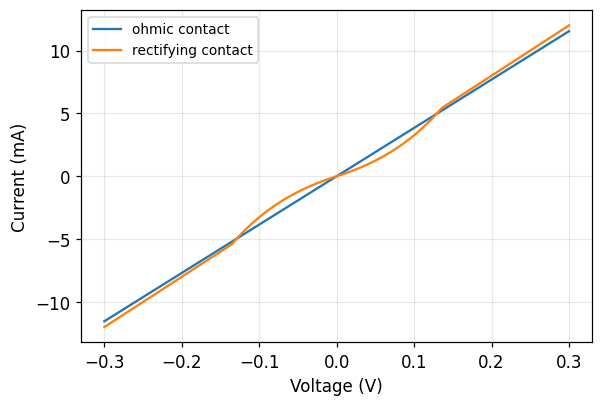

In [10]:
# --- failure mode 2: a rectifying contact ---
V = np.linspace(-0.3, 0.3, 301)
I_ohmic = th.iv_curve(V, 250.0, 1.0, 10.0, LT_mm=0.02)
I_schottky = th.iv_curve_schottky(V, R_ohm=25.0, I_sat=2e-3, n=2.0)

plt.figure(figsize=(5.6, 3.8))
plt.plot(V, I_ohmic * 1e3, label='ohmic contact')
plt.plot(V, I_schottky * 1e3, label='rectifying contact')
plt.xlabel('Voltage (V)'); plt.ylabel('Current (mA)')
plt.legend(fontsize=9); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'fit window (V)':>15}  {'R from ohmic':>13}  {'R from rectifying':>18}")
for vw in [(-0.05, 0.05), (-0.15, 0.15), (-0.3, 0.3)]:
    r_o = th.resistance_from_iv(V, I_ohmic, V_window=vw)
    r_s = th.resistance_from_iv(V, I_schottky, V_window=vw)
    print(f"  ±{abs(vw[0]):.2f}          {r_o:13.2f}  {r_s:18.2f}")

print("\nThe ohmic device gives the same resistance whatever window you fit.")
print("The rectifying one does not - and there is no single right answer.")

## 12. Running this on your own data

`tlm_helper.load_tlm_folder` reads a directory of measured I-V files into
exactly the structure `synthetic_tlm_dataset` produces, so everything above
works unchanged on real measurements:

```python
data = th.load_tlm_folder('./my_measurements', W_mm=10.0)
res, L, R_mean, R_std, warnings = th.analyse_tlm(data)
print(res.summary())
for w in warnings:
    print('!', w)
```

It expects one CSV per contact spacing, with the spacing in the file name
(`sample1_2.5mm.csv` → 2.5 mm), and one or more voltage/current column
pairs per file — one pair per repeated structure at that spacing. Exporters
that write a third column between sweeps are handled with
`columns_per_sweep=3`.

Before trusting any number that comes out:

- check every I-V curve is straight (`th.iv_linearity`, section 11);
- confirm the measurement was four-wire, or subtract the probe resistance;
- measure $W$ rather than taking it from the mask;
- read the validity report, and compare $L_T$ with your smallest spacing.

The cell below runs the whole chain end to end on the synthetic dataset,
which is the same three lines you would run on your own folder.

In [11]:
res_final, L_f, R_f, S_f, warnings = th.analyse_tlm(data)

print(res_final.summary())
print("\nvalidity report:", "nothing flagged" if not warnings else "")
for w in warnings:
    print("  ! " + w)

TLM extraction
--------------
  fit           R_T = 24.98 * L + 1.282   (R^2 = 1.00000)
  contact width W       = 10 mm
  sheet resist. R_S     = 249.8 +/- 0.18 ohm/sq
  contact res.  R_C     = 0.6409 +/- 0.013 ohm
  transfer len. L_T     = 0.02566 +/- 0.00053 mm
  contact resy. rho_C   = 0.001645 +/- 6.8e-05 ohm.cm^2

validity report: nothing flagged


## Summary of equations

| # | Equation | Meaning |
|---|---|---|
| (1) | $R_T = 2R_m + 2R_C + R_{\text{semi}}$ | what a two-probe measurement contains |
| (2) | $R_S = \rho/t$ | sheet resistance of a thin layer |
| (3) | $R_{\text{semi}} = R_S L/W$ | resistance of $L/W$ squares |
| (4) | $R_T = R_S L/W + 2R_C$ | linear TLM relation |
| (5) | $\rho_C = R_C A_{\text{eff}}$ | definition of specific contact resistivity |
| (6) | $I(x) = I_0 e^{-x/L_T}$ | current decay under the contact |
| (7) | $L_T = \sqrt{\rho_C/R_S}$ | transfer length |
| (8) | $A_{\text{eff}} = L_T W$ | effective current-transfer area |
| (9) | $R_C = \rho_C/(L_T W) = R_S L_T/W$ | resistance of one contact |
| (10) | $R_T = (R_S/W)(L + 2L_T)$ | the TLM equation |
| (11) | $I = V/R_T + I_{\text{offset}}$ | reducing one sweep to one resistance |
| (12) | $R_S = mW$ | sheet resistance from the slope |
| (13) | $R_C = b/2$ | contact resistance from the intercept |
| (14) | $L_T = b/(2m)$ | transfer length from both |
| (15) | $\rho_C = R_S L_T^2$ | the number to report |
| (16) | $\Delta\rho_C/\rho_C \approx 2\,\Delta b/b$ | why the intercept dominates the error |

Symbols: $L$ contact spacing, $W$ contact width, $d$ contact length,
$m$ fitted slope, $b$ fitted intercept.